# Multilingual SSD
Code for the work "Supervised Semantic Differential for Cross-Cultural Concept Analysis: A Case Study of Human Affect" by Jan Sikora, Paweł Lenartowicz, Hubert Plisiecki, available at: .

### Loading Dependencies

In [ ]:
!pip install python-docx -q
!pip install "git+https://github.com/hplisiecki/Supervised-Semantic-Differential.git@dev"
!pip install openpyxl
!pip install plskit

!python -m spacy download pl_core_news_lg -q
!python -m spacy download en_core_web_lg -q
!python -m spacy download fr_core_news_lg -q

print("Dependencies ready.")


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
DRIVE_PREFIX = "/content/drive/MyDrive/Multilingual SSD"

In [ ]:
import ssdiff
import plskit
import pandas as pd

In [ ]:
DATASETS = [
    {
        "name": "IMBIR_PL_Multilingual",
        "data": f"{DRIVE_PREFIX}/Multilingual Lexicons/IMBIR/DataSheet1.XLSX",
        "model": f"{DRIVE_PREFIX}/models/wiki.multi.pl.vec",
        "language": "pl",
        "spacy_model": "pl_core_news_lg",
        "stopwords_lang": "pl",
        "word_col": "polish word",
        "columns": ["Valence_M", "arousal_M", "dominance_M"]
    },
    {
        "name": "IMBIR_PL_Monolingual",
        "data": f"{DRIVE_PREFIX}/Multilingual Lexicons/IMBIR/DataSheet1.XLSX",
        "model": f"{DRIVE_PREFIX}/models/glove_300_3_polish.kv",
        "language": "pl",
        "spacy_model": "pl_core_news_lg",
        "stopwords_lang": "pl",
        "word_col": "polish word",
        "columns": ["Valence_M", "arousal_M", "dominance_M"]
    },
    {
        "name": "Warriner_EN_Multilingual",
        "data": f"{DRIVE_PREFIX}/Multilingual Lexicons/Warriner/Ratings_VAD_WarrinerEtAl.csv",
        "model": f"{DRIVE_PREFIX}/models/wiki.multi.en.vec.txt",
        "language": "en",
        "spacy_model": "en_core_web_lg",
        "stopwords_lang": "en",
        "word_col": "word",
        "columns": ["valence", "arousal", "dominance"]
    },
    {
        "name": "Warriner_EN_Monolingual",
        "data": f"{DRIVE_PREFIX}/Multilingual Lexicons/Warriner/Ratings_VAD_WarrinerEtAl.csv",
        "model": f"{DRIVE_PREFIX}/models/dolma_300_2024_1.2M.100_combined.kv",
        "language": "en",
        "spacy_model": "en_core_web_lg",
        "stopwords_lang": "en",
        "word_col": "word",
        "columns": ["valence", "arousal", "dominance"]
    },
    {
        "name": "FAN_FR_Multilingual",
        "data": f"{DRIVE_PREFIX}/Multilingual Lexicons/FAN/fan.xlsx",
        "model": f"{DRIVE_PREFIX}/models/wiki.multi.fr.vec",
        "language": "fr",
        "spacy_model": "fr_core_news_lg",
        "stopwords_lang": "fr",
        "word_col": "French",
        "columns": ["valence_all_mean", "arousal_all_mean"]
    },
    {
        "name": "FAN_FR_Monolingual",
        "data": f"{DRIVE_PREFIX}/Multilingual Lexicons/FAN/fan.xlsx",
        "model": f"{DRIVE_PREFIX}/models/frWac_no_postag_no_phrase_500_skip_cut100.bin",
        "language": "fr",
        "spacy_model": "fr_core_news_lg",
        "stopwords_lang": "fr",
        "word_col": "French",
        "columns": ["valence_all_mean", "arousal_all_mean"]
    },
]

### Setting hyperparameters and data paths

In [ ]:
# %% ── CELL 2: CONFIGURATION — adjusted for multi-dataset loop
import os

# Global hyperparameters
SIF_A             = 1e-2
CLUSTER_TOPN      = 100   # neighbours pulled per pole before clustering
CLUSTER_K_MIN     = 2     # auto-k cluster sweep bounds (delta-gradient cell)
CLUSTER_K_MAX     = 5
CLUSTER_TOP_WORDS = 10    # words shown per cluster in reports
SNIPPET_MAX_CHARS = 300

# Cross-language permutation tests (CELL 7)
PERM_N        = 1000  # permutations per test
PERM_SEED     = 2137
OUT_DIR       = f"{DRIVE_PREFIX}/multilingual_output"
REPORT_TITLE  = "SSD Multilingual Analysis Report"

os.makedirs(OUT_DIR, exist_ok=True)
print(f"Global config loaded. Results will be saved to: {OUT_DIR}")

Global config loaded. Results will be saved to: /content/drive/MyDrive/Multilingual SSD/multilingual_output


### Loading Data and embeddings along with normalization

In [ ]:
import pickle
import warnings

import pandas as pd

from ssdiff import Corpus, Embeddings, SSD

warnings.filterwarnings("ignore")

all_results = {}

for ds_config in DATASETS:
    ds_name = ds_config["name"]
    print(f"\n{'#'*80}")
    print(f"### PROCESSING DATASET: {ds_name} ({ds_config['language']})")
    print(f"{'#'*80}")

    # ── Load Data ──────────────────────────────────────────────────────────────
    data_path = ds_config["data"]
    df_raw = pd.read_excel(data_path) if data_path.lower().endswith(".xlsx") else pd.read_csv(data_path)

    TEXT_COL = ds_config["word_col"]
    print(f"[{ds_name}] Using text column: '{TEXT_COL}'")

    score_cols = ds_config["columns"]
    df = df_raw.dropna(subset=[TEXT_COL] + score_cols).reset_index(drop=True)
    texts = df[TEXT_COL].astype(str).tolist()

    # ── Load Embeddings: prefer cached normalized .ssdembed, else build it ────────
    # The .ssdembed cache stores the L2+ABTT-normalized vectors and round-trips the
    # normalization flags, so re-calling .normalize() on a cache hit is a no-op.

    cache_base = os.path.splitext(ds_config["model"])[0] + "_norm"
    cache_path = cache_base + ".ssdembed"
    try:
        emb = Embeddings.load(cache_path, ram_efficient=True)
        print(f"[{ds_name}] Loaded cached embeddings: {cache_path}")
    except (FileNotFoundError, OSError):
        # Missing cache, or a missing/corrupt .vectors.npy sidecar — rebuild
        # the normalized cache (the only full-vocab load), then reload partial.
        print(f"[{ds_name}] Cache miss — loading raw {ds_config['model']}...")
        Embeddings.load(ds_config["model"]).normalize(l2=True, abtt=1).save(cache_base)
        emb = Embeddings.load(cache_path, ram_efficient=True)
        print(f"[{ds_name}] Saved normalized cache: {cache_path}")

    # ── Preprocessing (spaCy + stopwords handled inside Corpus) ─────────────────
    print(f"[{ds_name}] Preprocessing texts...")
    corpus = Corpus(
        texts,
        model=ds_config["spacy_model"],
        lang=ds_config["stopwords_lang"],
    )

    # ── PLS per dimension ────────────────────────────────────────────────────────
    ds_results = {}
    for dim in score_cols:
        print(f"\n--- Dimension: {dim} ({ds_name}) ---")
        y = df[dim].values

        # SSD drops empty docs / NaN-y internally via its keep-mask.
        ssd = SSD(emb, corpus, y, use_full_doc=True, sif_a=SIF_A)

        # PLS1 — k auto-selected (find_k_optimal), split-half significance test.
        pls = ssd.fit_pls(verbose=True)

        # Materialize sided cluster words + snippets so they're cached on the result.
        _ = pls.clusters.pos(topn=CLUSTER_TOPN).words
        _ = pls.clusters.neg(topn=CLUSTER_TOPN).words
        _ = pls.snippets

        ds_results[dim] = pls  # carries .stats .test .words .clusters .snippets .report()

    all_results[ds_name] = {"results": ds_results, "df": df, "corpus": corpus}

pkl_path = os.path.join(OUT_DIR, "multilingual_ssd_results_v2.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(all_results, f)
print(f"\nFinished all datasets. Results saved to {pkl_path}")


################################################################################
### PROCESSING DATASET: IMBIR_PL_Multilingual (pl)
################################################################################
[IMBIR_PL_Multilingual] Using text column: 'polish word'
[IMBIR_PL_Multilingual] Loaded cached embeddings: /content/drive/MyDrive/Multilingual SSD/models/wiki.multi.pl_norm.ssdembed
[IMBIR_PL_Multilingual] Preprocessing texts...

--- Dimension: Valence_M (IMBIR_PL_Multilingual) ---
[fit_pls] auto-selecting k via find_k_optimal (selector=r2_se, k_max=5)
[fit_pls] k_star = 3
[fit_pls] diagnostic chain (split_nb, k=1..3): 6.67e-36, 1.49e-19, 4.91e-11
        path-max: 4.91e-11  [same-sample, not honest — informational only]
[fit_pls] running k=1 confirmatory test (split_nb, n_splits=50)
[fit_pls] honest p (k=1) = 1.9583e-35

--- Dimension: arousal_M (IMBIR_PL_Multilingual) ---
[fit_pls] auto-selecting k via find_k_optimal (selector=r2_se, k_max=5)
[fit_pls] k_star = 3
[fit_pls] 

In [ ]:
import numpy as np


def _fmt_p(p):
    if not np.isfinite(p):
        return "n/a"
    return f"{p}"


summary_rows = []

for ds_name, ds_data in all_results.items():
    for dim, res in ds_data["results"].items():   # res is the PLSResult
        st = res.stats
        summary_rows.append({
            "Dataset":   ds_name,
            "Dimension": dim,
            "N_Kept":    st.n_kept,
            "K":         res.fit_info.n_components,
            "R2":        f"{st.r2:.3f}",
            "p_val":     _fmt_p(st.pvalue),
            "r_pred":    f"{st.y_corr_pred:.3f}",
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Dataset,Dimension,N_Kept,K,R2,p_val,r_pred
0,IMBIR_PL_Multilingual,Valence_M,3584,3,0.578,1.958297060800592e-35,0.760
1,IMBIR_PL_Multilingual,arousal_M,3584,3,0.542,5.421490067261914e-38,0.736
2,IMBIR_PL_Multilingual,dominance_M,3584,3,0.463,1.5262847291584616e-28,0.680
3,IMBIR_PL_Monolingual,Valence_M,4656,3,0.662,1.535605654594182e-39,0.813
4,IMBIR_PL_Monolingual,arousal_M,4656,3,0.590,8.831978198636853e-42,0.768
5,IMBIR_PL_Monolingual,dominance_M,4656,3,0.576,2.745146498159039e-37,0.759
6,Warriner_EN_Multilingual,valence,13541,4,0.584,1.0435556630169477e-50,0.764
7,Warriner_EN_Multilingual,arousal,13541,4,0.360,5.470622943108509e-44,0.600
8,Warriner_EN_Multilingual,dominance,13541,4,0.459,1.9895155114335768e-51,0.678
9,Warriner_EN_Monolingual,valence,13814,5,0.627,5.604349766680341e-53,0.792


In [ ]:
pkl_path = os.path.join(OUT_DIR, "multilingual_ssd_results_v2.pkl")
with open(pkl_path, "rb") as f:
    all_results = pickle.load(f)
print(f"Loaded all_results from {pkl_path}")

Loaded all_results from /content/drive/MyDrive/Multilingual SSD/multilingual_output/multilingual_ssd_results_v2.pkl


In [ ]:
from IPython.display import HTML, display

for ds_name, ds_data in all_results.items():
    display(HTML(f"<h2 style='padding: 10px;'>Dataset: {ds_name}</h1>"))

    for dim, res in ds_data["results"].items():
        display(HTML(f"<h3 style='border-bottom: 2px solid #444;'>Dimension: {dim}</h2>"))

        # Built-in narrative report (Stats + Fit info always included).
        report = res.report(
            clusters={"n": 5, "n_words": CLUSTER_TOP_WORDS, "n_snippets": 0},
            top_words=False,
            extreme_docs=False,
            misdiagnosed=True,
        )
        display(HTML(report.to_html()))

### Semantic Difference (Delta) Gradients

In this section, we calculate the vector difference between language semantic gradients ($ \vec{\beta}_{a} - \vec{\beta}_{b} $). We then perform neighbor clustering on these difference vectors to see which semantic regions are responsible for the 'shift' in meaning across languages.

In [ ]:
import numpy as np
from IPython.display import HTML, display

from ssdiff.utils.neighbors import cluster_top_neighbors

delta_results = {}

ds_pairs = [
    ("IMBIR_PL_Multilingual", "Warriner_EN_Multilingual"),
    ("IMBIR_PL_Multilingual", "FAN_FR_Multilingual"),
    ("Warriner_EN_Multilingual", "FAN_FR_Multilingual"),
]


def _top_words(words, n):
    return ", ".join(w["word"] for w in words[:n])


for a, b in ds_pairs:
    res_a, res_b = all_results[a]["results"], all_results[b]["results"]

    for dim in ["valence", "arousal", "dominance"]:
        if dim not in res_a or dim not in res_b:
            continue

        pls_a, pls_b = res_a[dim], res_b[dim]

        # Unit gradients come straight off the result (.gradient = unit β).
        delta = pls_a.gradient - pls_b.gradient
        delta /= np.linalg.norm(delta)

        delta_results.setdefault((a, b), {})[dim] = {}

        display(HTML(f"<h3 style='border-bottom:2px solid #444'>{a} vs {b} — {dim}</h3>"))

        # Resolve the delta direction's neighbour-clusters in each language's space.
        for pls_base, lang_id in [(pls_a, a), (pls_b, b)]:
            display(HTML(f"<h4>neighbours in {lang_id} space</h4>"))
            sides = {}
            for side in ("pos", "neg"):
                lean = a if side == "pos" else b
                raw = cluster_top_neighbors(
                    pls_base.embeddings, delta,
                    topn=CLUSTER_TOPN, k_min=CLUSTER_K_MIN, k_max=CLUSTER_K_MAX,
                    side=side, lang=pls_base.lang or "pl",
                )
                sides[side] = raw
                color = "#d4edda" if side == "pos" else "#f8d7da"
                display(HTML(
                    f"<h5 style='background-color:{color}; padding:4px'>"
                    f"{side} pole (leans → {lean})</h5>"
                ))
                for c in sorted(raw, key=lambda c: c["id"]):
                    tw = _top_words(c["words"], CLUSTER_TOP_WORDS)
                    display(HTML(
                        f"<div style='border-left:4px solid #555; padding:6px 12px; margin:3px 0'>"
                        f"<b>Cluster {c['id']}</b> &nbsp;"
                        f"<span style='font-size:0.9em'>n={c['size']} &nbsp;"
                        f"cos={c['centroid_cos_beta']:.2f} &nbsp;"
                        f"coherence={c['coherence']:.2f}</span><br>"
                        f"<span style='font-family:monospace; font-size:0.95em'>{tw}</span>"
                        f"</div>"
                    ))
            delta_results[(a, b)][dim][lang_id] = sides

print("Delta Gradient calculation complete.")

# =========================

Delta Gradient calculation complete.


### Permutation tests and bootstraping


=== IMBIR_PL_Multilingual vs Warriner_EN_Multilingual — valence ===
observed cos(g_a, g_b) = +0.8795   (k=1, PERM_N=1000)
  TEST 1 (cos=0):        cos_obs=+0.8795  null_mean=-0.0038  p_raw=0.0010
  TEST 2 (grads equal):  cos_obs=+0.8795  null_mean=+0.9803  p_raw=0.0010
  SAMPLING-ERROR CI:     cos_obs=+0.8795  95% CI [+0.8656, +0.8921]  (Fisher-z SE, B=1000)


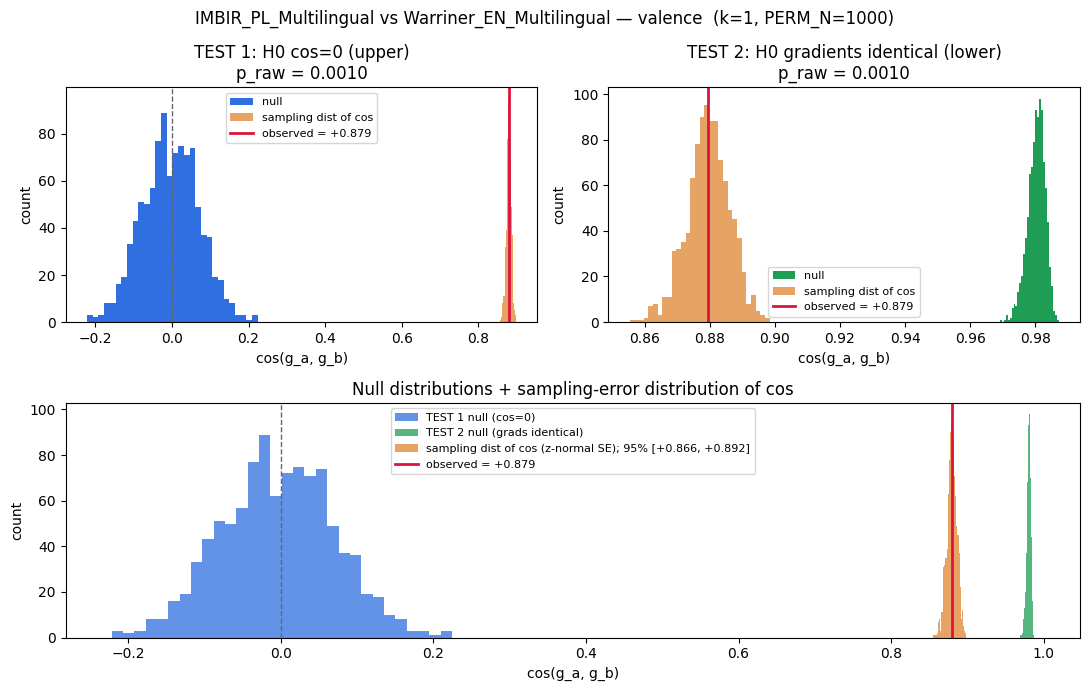


=== IMBIR_PL_Multilingual vs Warriner_EN_Multilingual — arousal ===
observed cos(g_a, g_b) = +0.8050   (k=1, PERM_N=1000)
  TEST 1 (cos=0):        cos_obs=+0.8050  null_mean=-0.0000  p_raw=0.0010
  TEST 2 (grads equal):  cos_obs=+0.8050  null_mean=+0.9730  p_raw=0.0010
  SAMPLING-ERROR CI:     cos_obs=+0.8050  95% CI [+0.7858, +0.8226]  (Fisher-z SE, B=1000)


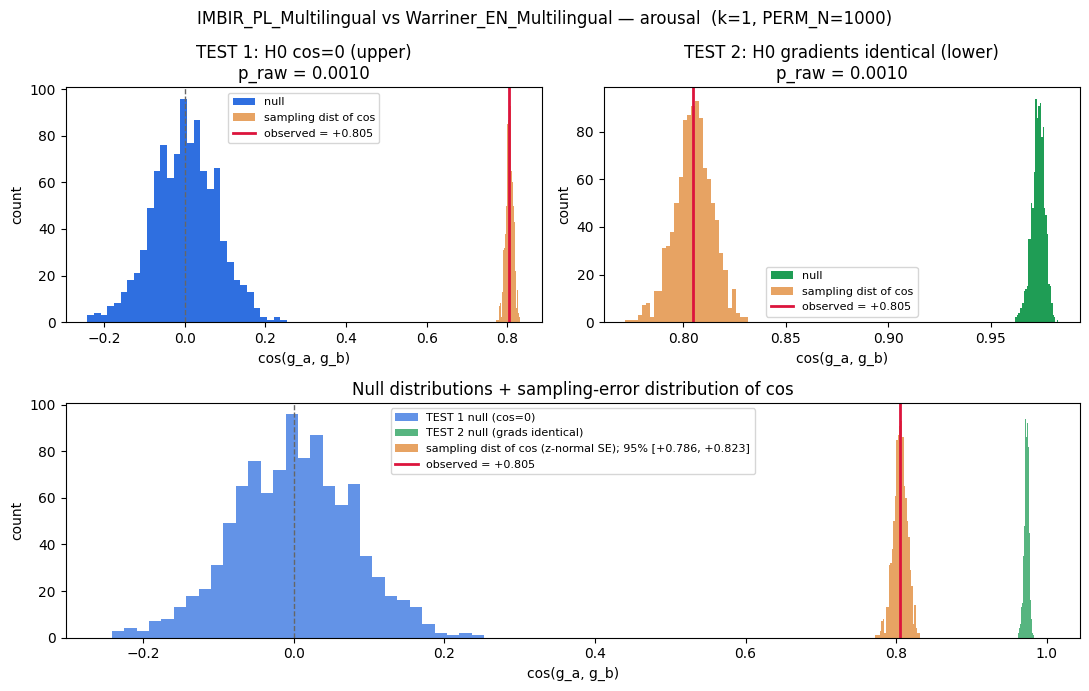


=== IMBIR_PL_Multilingual vs Warriner_EN_Multilingual — dominance ===
observed cos(g_a, g_b) = +0.6816   (k=1, PERM_N=1000)
  TEST 1 (cos=0):        cos_obs=+0.6816  null_mean=+0.0002  p_raw=0.0010
  TEST 2 (grads equal):  cos_obs=+0.6816  null_mean=+0.9717  p_raw=0.0010
  SAMPLING-ERROR CI:     cos_obs=+0.6816  95% CI [+0.6423, +0.7173]  (Fisher-z SE, B=1000)


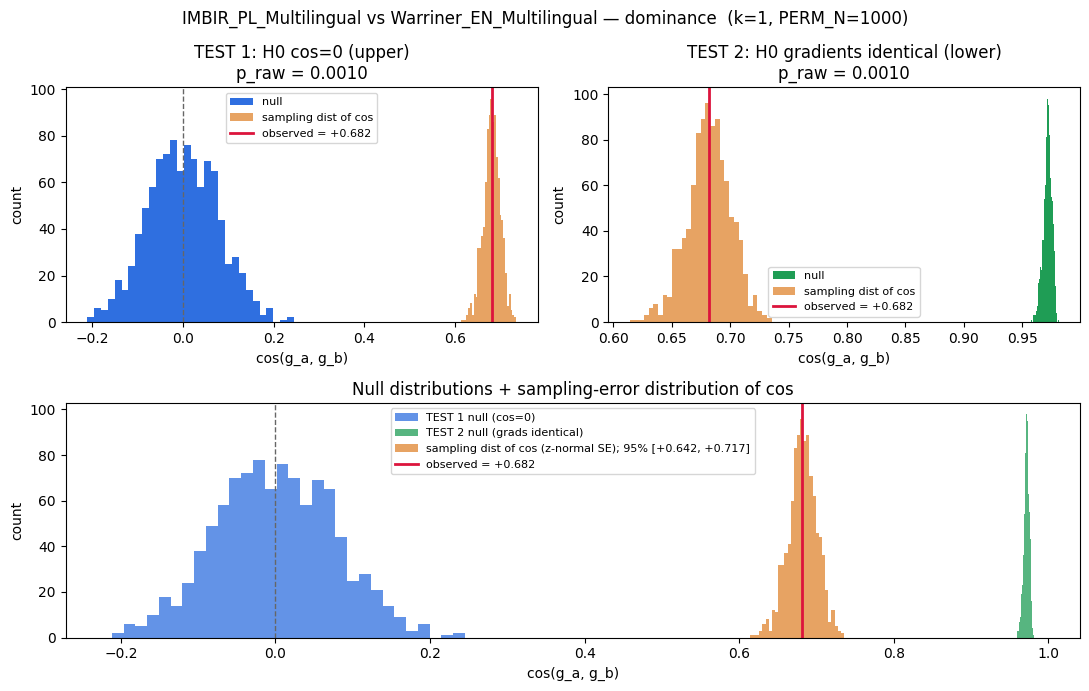


=== IMBIR_PL_Multilingual vs FAN_FR_Multilingual — valence ===
observed cos(g_a, g_b) = +0.6977   (k=1, PERM_N=1000)
  TEST 1 (cos=0):        cos_obs=+0.6977  null_mean=-0.0033  p_raw=0.0010
  TEST 2 (grads equal):  cos_obs=+0.6977  null_mean=+0.9102  p_raw=0.0010
  SAMPLING-ERROR CI:     cos_obs=+0.6977  95% CI [+0.6416, +0.7463]  (Fisher-z SE, B=1000)


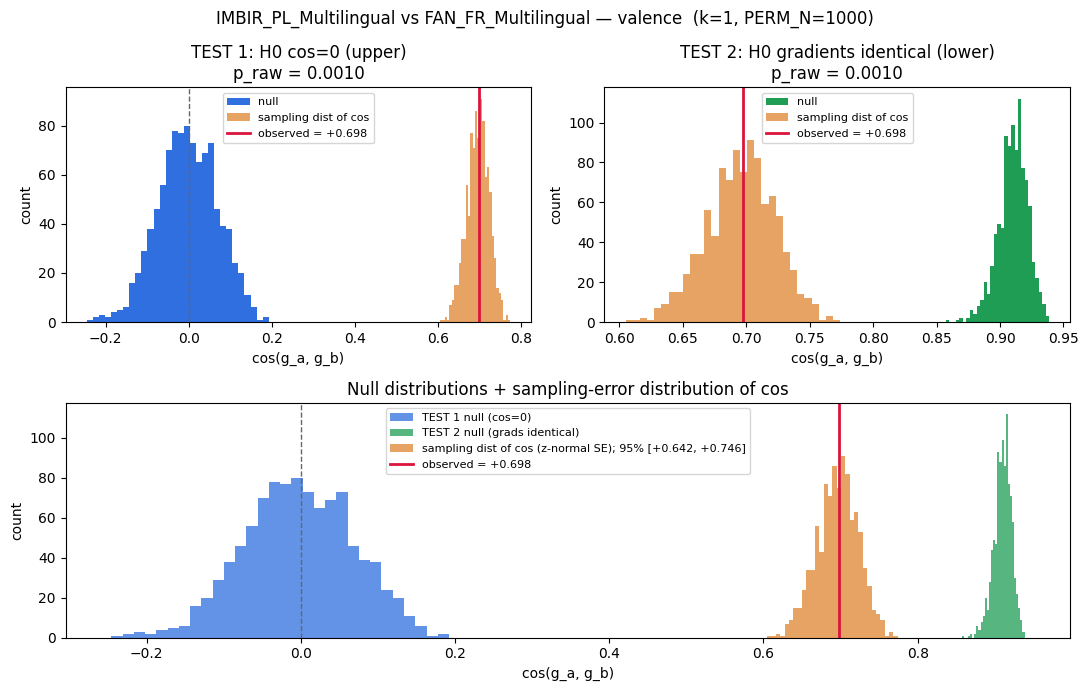


=== IMBIR_PL_Multilingual vs FAN_FR_Multilingual — arousal ===
observed cos(g_a, g_b) = +0.6985   (k=1, PERM_N=1000)
  TEST 1 (cos=0):        cos_obs=+0.6985  null_mean=-0.0058  p_raw=0.0010
  TEST 2 (grads equal):  cos_obs=+0.6985  null_mean=+0.9451  p_raw=0.0010
  SAMPLING-ERROR CI:     cos_obs=+0.6985  95% CI [+0.6529, +0.7391]  (Fisher-z SE, B=1000)


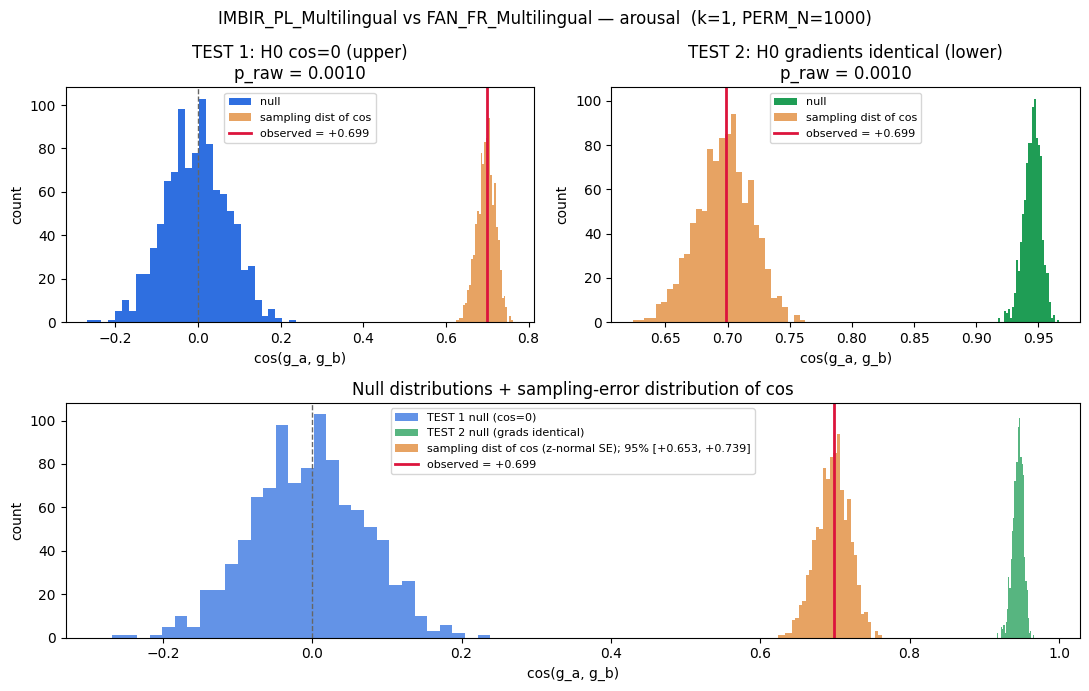

  SKIP dominance: no 'dominance*' key in FAN_FR_Multilingual (have: ['valence_all_mean', 'arousal_all_mean'])

=== Warriner_EN_Multilingual vs FAN_FR_Multilingual — valence ===
observed cos(g_a, g_b) = +0.7505   (k=1, PERM_N=1000)
  TEST 1 (cos=0):        cos_obs=+0.7505  null_mean=+0.0014  p_raw=0.0010
  TEST 2 (grads equal):  cos_obs=+0.7505  null_mean=+0.9447  p_raw=0.0010
  SAMPLING-ERROR CI:     cos_obs=+0.7505  95% CI [+0.6911, +0.7998]  (Fisher-z SE, B=1000)


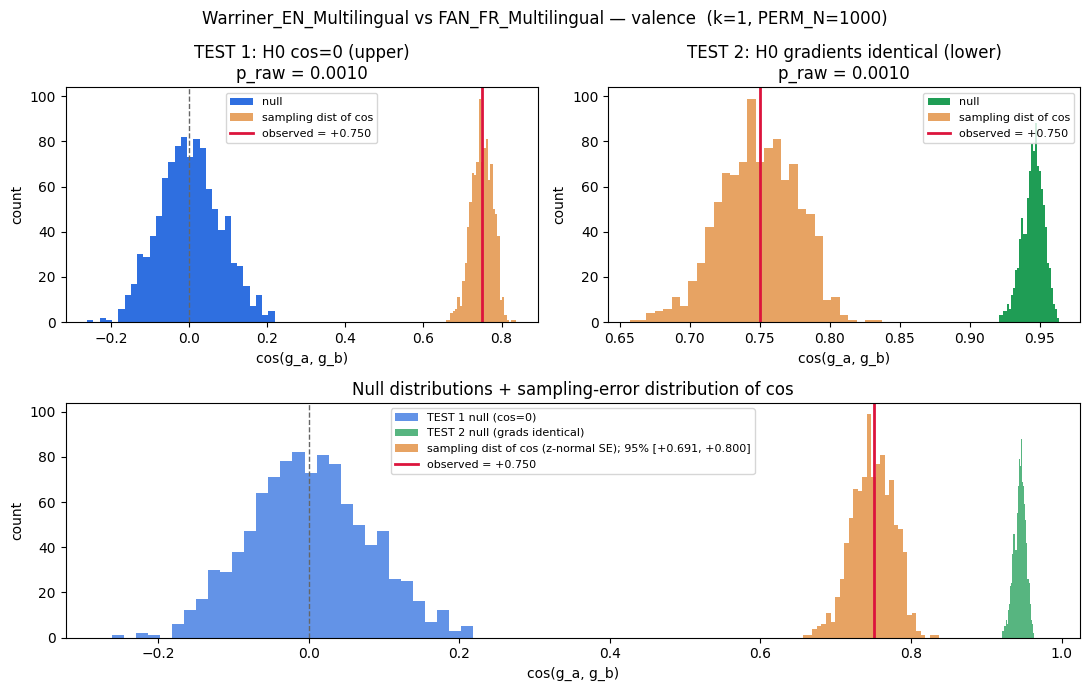


=== Warriner_EN_Multilingual vs FAN_FR_Multilingual — arousal ===
observed cos(g_a, g_b) = +0.6871   (k=1, PERM_N=1000)
  TEST 1 (cos=0):        cos_obs=+0.6871  null_mean=-0.0024  p_raw=0.0010
  TEST 2 (grads equal):  cos_obs=+0.6871  null_mean=+0.9159  p_raw=0.0010
  SAMPLING-ERROR CI:     cos_obs=+0.6871  95% CI [+0.6354, +0.7328]  (Fisher-z SE, B=1000)


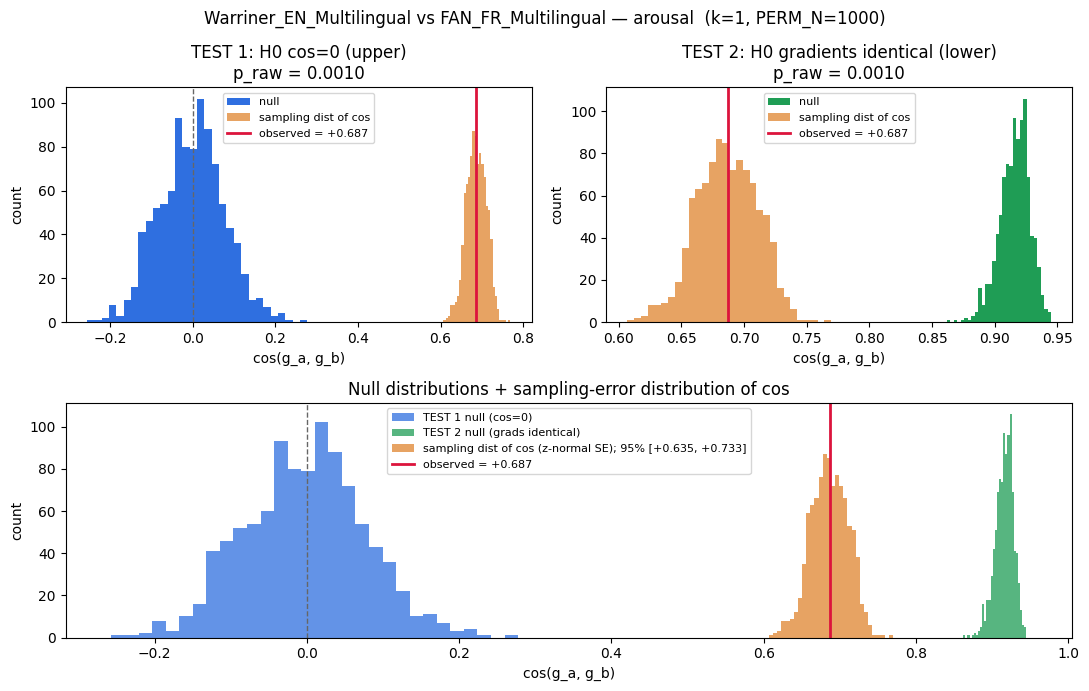

  SKIP dominance: no 'dominance*' key in FAN_FR_Multilingual (have: ['valence_all_mean', 'arousal_all_mean'])


In [ ]:
# %% ── CELL 7: CROSS-LANGUAGE PERMUTATION TESTS ───────────────────────────────
# Two complementary nulls on the cross-lingual gradient cosine cos(g_a, g_b):
#
#   TEST 1  H0: cos = 0 (gradients unrelated). Shuffle word<->value WITHIN each
#           dataset independently, refit PLS, recompute cos. Rejecting => the two
#           languages' dimensions are ALIGNED beyond chance. One-sided upper.
#
#   TEST 2  H0: gradients identical (cos = 1). Pool both datasets, z-score y
#           within each first, permute the language label (group sizes fixed),
#           refit PLS per pseudo-language, recompute cos. Under H0 the random
#           splits give high cos, so a real difference shows as observed cos in
#           the LOWER tail. Rejecting => the languages DIFFER. One-sided lower.
#           NOTE: full vocab — this test conflates a true gradient difference
#           with X-composition differences between the languages (exchangeability
#           is only approximate). Read as "same language-conditioned process".

import matplotlib.pyplot as plt
import numpy as np

from ssdiff.utils.math import standardize

PERM_PAIRS = [
    ("IMBIR_PL_Multilingual", "Warriner_EN_Multilingual"),
    ("IMBIR_PL_Multilingual", "FAN_FR_Multilingual"),
    ("Warriner_EN_Multilingual", "FAN_FR_Multilingual"),
]
PERM_DIMS  = ["valence", "arousal", "dominance"]


def _k1_dirs(Xs, inv_scale, Ys):
    """Closed-form k=1 PLS1 unit gradient(s). beta ∝ (Xs^T y) / scale; no sign
    flip (orientation is provably positive at k=1). Ys is (n, m) standardized-y
    columns → (D, m) unit gradients. Batched: m columns in one matmul."""
    B = (Xs.T @ Ys) * inv_scale[:, None]
    return B / np.maximum(np.linalg.norm(B, axis=0, keepdims=True), 1e-12)


def _pls1_gradient(x, y):
    """Closed-form k=1 PLS1 unit gradient for one (x, y), standardizing both."""
    Xs, _, sc = standardize(np.asarray(x, float))
    ys = standardize(np.asarray(y, float).reshape(-1, 1))[0].ravel()
    inv = 1.0 / np.where(sc > 1e-12, sc, 1.0)
    return _k1_dirs(Xs, inv, ys[:, None])[:, 0]


def _perm_pvalue(null, observed, tail="upper"):
    """One-sided permutation p-value (raw, uncorrected). tail='upper' counts
    null >= observed; tail='lower' counts null <= observed."""
    null = np.asarray(null, float)
    hits = np.sum(null <= observed) if tail == "lower" else np.sum(null >= observed)
    return float((hits + 1) / (len(null) + 1))


def _resolve_dim(results, canon):
    """Map a canonical dim ('valence') to a dataset's actual key, whatever its
    raw spelling — 'Valence_M', 'valence', 'valence_all_mean'. CELL-4-agnostic."""
    for key in results:
        if key.lower().startswith(canon):
            return key
    return None


perm_results = {}

for a, b in PERM_PAIRS:
    res_a, res_b = all_results[a]["results"], all_results[b]["results"]
    for dim in PERM_DIMS:
        key_a, key_b = _resolve_dim(res_a, dim), _resolve_dim(res_b, dim)
        if key_a is None or key_b is None:
            for n, k in [(a, key_a), (b, key_b)]:
                if k is None:
                    print(f"  SKIP {dim}: no '{dim}*' key in {n} "
                          f"(have: {list(all_results[n]['results'])})")
            continue
        pls_a, pls_b = res_a[key_a], res_b[key_b]
        x_a, y_a = np.asarray(pls_a.x, float), np.asarray(pls_a.y, float)
        x_b, y_b = np.asarray(pls_b.x, float), np.asarray(pls_b.y, float)
        rng = np.random.default_rng(PERM_SEED)
        print(f"\n=== {a} vs {b} — {dim} ===")

        # Standardize once: X is fixed across TEST 1, and y here is z-scored
        # within dataset (also reused as the pooled y for TEST 2).
        Xs_a, _, sc_a = standardize(x_a)
        Xs_b, _, sc_b = standardize(x_b)
        inv_a = 1.0 / np.where(sc_a > 1e-12, sc_a, 1.0)
        inv_b = 1.0 / np.where(sc_b > 1e-12, sc_b, 1.0)
        ys_a = standardize(y_a.reshape(-1, 1))[0].ravel()
        ys_b = standardize(y_b.reshape(-1, 1))[0].ravel()

        # Observed (same closed form as the null).
        g_a = _k1_dirs(Xs_a, inv_a, ys_a[:, None])[:, 0]
        g_b = _k1_dirs(Xs_b, inv_b, ys_b[:, None])[:, 0]
        cos_obs = float(g_a @ g_b)
        print(f"observed cos(g_a, g_b) = {cos_obs:+.4f}   (k=1, PERM_N={PERM_N})")

        # --- TEST 1: cos=0 null — permute y within each dataset (X fixed). ---
        # Both nulls collapse to one (Xs^T @ Ys) matmul each.
        Ys_a = np.stack([rng.permutation(ys_a) for _ in range(PERM_N)], axis=1)
        Ys_b = np.stack([rng.permutation(ys_b) for _ in range(PERM_N)], axis=1)
        null_cos = (_k1_dirs(Xs_a, inv_a, Ys_a) * _k1_dirs(Xs_b, inv_b, Ys_b)).sum(0)
        p_align = _perm_pvalue(null_cos, cos_obs, tail="upper")

        # --- TEST 2: gradients-identical null — pooled language-label shuffle. ---
        # y already z-scored within dataset; each pseudo-group is re-standardized
        # on its own rows (mirrors a per-group PLS fit), so this one must loop.
        x_pool = np.vstack([x_a, x_b])
        yz_pool = np.concatenate([ys_a, ys_b])
        n_a = len(x_a)
        idx = np.arange(len(x_pool))
        null_cos2 = np.empty(PERM_N)
        for i in range(PERM_N):
            rng.shuffle(idx)
            ia, ib = idx[:n_a], idx[n_a:]
            null_cos2[i] = _pls1_gradient(x_pool[ia], yz_pool[ia]) @ \
                _pls1_gradient(x_pool[ib], yz_pool[ib])
        p_diff = _perm_pvalue(null_cos2, cos_obs, tail="lower")

        # --- Bootstrap sampling-error CI on the observed cosine. ---
        # Resample (word, value) pairs WITH replacement within each dataset,
        # refit both k=1 gradients (re-standardized per resample), recompute
        # cos. We want the PRECISION of cos_obs (its sampling error), not the
        # true/disattenuated effect — so we use the bootstrap only for the
        # SPREAD and center the interval on cos_obs, discarding the bootstrap's
        # (downward attenuation) bias. The SE is measured on the Fisher-z scale
        # (arctanh), where the cos<=1 boundary maps to +inf and the spread is
        # geometry-stabilized, then back-transformed with tanh — so the
        # interval can never cross 1. Own RNG so the tests stay bit-identical.
        n_b = len(x_b)
        rng_boot = np.random.default_rng(PERM_SEED + 1)
        boot = np.empty(PERM_N)
        for i in range(PERM_N):
            ia = rng_boot.integers(n_a, size=n_a)
            ib = rng_boot.integers(n_b, size=n_b)
            boot[i] = _pls1_gradient(x_a[ia], y_a[ia]) @ \
                _pls1_gradient(x_b[ib], y_b[ib])
        z_obs = float(np.arctanh(np.clip(cos_obs, -1 + 1e-12, 1 - 1e-12)))
        z_boot = np.arctanh(np.clip(boot, -1 + 1e-12, 1 - 1e-12))
        se_z = float(z_boot.std(ddof=1))         # sampling-error SE in z-space
        ci_lo = float(np.tanh(z_obs - 1.96 * se_z))
        ci_hi = float(np.tanh(z_obs + 1.96 * se_z))
        # Sampling-error distribution for the plot: an artificial normal on the
        # Fisher-z scale, N(z_obs, se_z), back-transformed with tanh. Centered
        # on the estimate (bias dropped), carries the bootstrap SE as its
        # spread, boundary-aware (slightly skewed in cos space) — the histogram
        # form of cos_obs +/- the SE.
        cos_samp = np.tanh(rng_boot.normal(z_obs, se_z, size=PERM_N))

        perm_results[(a, b, dim)] = {
            "cos_obs": cos_obs,
            "p_alignment": p_align,      # H0: cos = 0       (raw, upper-tail)
            "null_cos_mean": float(null_cos.mean()),
            "p_difference": p_diff,      # H0: cos = 1 / same (raw, lower-tail)
            "null_cos2_mean": float(null_cos2.mean()),
            "boot_ci": (ci_lo, ci_hi),   # 95% sampling-error CI (Fisher-z SE)
            "boot_se_z": se_z,
        }

        print(f"  TEST 1 (cos=0):        cos_obs={cos_obs:+.4f}  "
              f"null_mean={null_cos.mean():+.4f}  p_raw={p_align:.4f}")
        print(f"  TEST 2 (grads equal):  cos_obs={cos_obs:+.4f}  "
              f"null_mean={null_cos2.mean():+.4f}  p_raw={p_diff:.4f}")
        print(f"  SAMPLING-ERROR CI:     cos_obs={cos_obs:+.4f}  "
              f"95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]  (Fisher-z SE, B={PERM_N})")

        # --- Null-distribution histograms (observed = red line) ---
        C1, C2 = "#2f6fe0", "#1f9d55"   # TEST 1 (blue), TEST 2 (green)
        C3 = "#e0852f"                  # bootstrap of observed cos (orange)

        def _draw_null(ax, null, color, observed, *, zero_line, title):
            ax.hist(null, bins=30, color=color, label="null")
            ax.hist(cos_samp, bins=30, color=C3, alpha=0.75,
                    label="sampling dist of cos")
            if zero_line:
                ax.axvline(0.0, color="0.4", ls="--", lw=1)
            ax.axvline(observed, color="crimson", lw=2,
                       label=f"observed = {observed:+.3f}")
            ax.set_title(title)
            ax.set_xlabel("cos(g_a, g_b)")
            ax.set_ylabel("count")
            ax.legend(fontsize=8)

        fig = plt.figure(figsize=(11, 7))
        gs = fig.add_gridspec(2, 2)        # bottom panel spans full width
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax3 = fig.add_subplot(gs[1, :])
        fig.suptitle(f"{a} vs {b} — {dim}  (k=1, PERM_N={PERM_N})")

        _draw_null(ax1, null_cos, C1, cos_obs, zero_line=True,
                   title=f"TEST 1: H0 cos=0 (upper)\np_raw = {p_align:.4f}")
        _draw_null(ax2, null_cos2, C2, cos_obs, zero_line=False,
                   title=f"TEST 2: H0 gradients identical (lower)\n"
                         f"p_raw = {p_diff:.4f}")

        # Combined: both nulls on a shared axis.
        ax3.hist(null_cos, bins=30, color=C1, alpha=0.75,
                 label="TEST 1 null (cos=0)")
        ax3.hist(null_cos2, bins=30, color=C2, alpha=0.75,
                 label="TEST 2 null (grads identical)")
        ax3.hist(cos_samp, bins=30, color=C3, alpha=0.75,
                 label=f"sampling dist of cos (z-normal SE); "
                       f"95% [{ci_lo:+.3f}, {ci_hi:+.3f}]")
        ax3.axvline(0.0, color="0.4", ls="--", lw=1)
        ax3.axvline(cos_obs, color="crimson", lw=2,
                    label=f"observed = {cos_obs:+.3f}")
        ax3.set_title("Null distributions + sampling-error distribution of cos")
        ax3.set_xlabel("cos(g_a, g_b)")
        ax3.set_ylabel("count")
        ax3.legend(fontsize=8)

        fig.tight_layout()
        plt.show()
